In [14]:
import torch

DEVICE = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")
print(f"PyTorch version: {torch.__version__}, CUDA available: {torch.cuda.is_available()}")

import numpy as np

# Suppress warnings (optional)
import warnings

warnings.filterwarnings('ignore')

SEED = 42
BATCH_SIZE = 64
HEIGHT, WIDTH = 224, 224

torch.manual_seed(SEED)
np.random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)

import os

TRAIN_DIR = os.path.join(os.getcwd(), 'data', 'chest_xray', 'train')
VALIDATION_DIR = os.path.join(os.getcwd(), 'data', 'chest_xray', 'test')

Using device: cuda:0
PyTorch version: 2.7.1+cu118, CUDA available: True


In [17]:
from torchvision import transforms, datasets
from torch.utils.data import DataLoader

train_transformation = transforms.Compose([transforms.Resize((HEIGHT, WIDTH)),
                                           transforms.RandomHorizontalFlip(p=0.5),
                                           transforms.RandomRotation(5),
                                           transforms.RandomAffine(degrees=0, translate=(0.05, 0.05)),
                                           transforms.ColorJitter(brightness=0.1, contrast=0.1),
                                           transforms.ToTensor(),
                                           transforms.Normalize(mean=[0.485, 0.456, 0.406],  # ImageNet normalization
                                                                std=[0.229, 0.224, 0.225])
                                           ])

validation_transformation = transforms.Compose([transforms.Resize((HEIGHT, WIDTH)),
                                                transforms.ToTensor(),
                                                transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                                                     std=[0.229, 0.224, 0.225])
                                                ])

train_ds = datasets.ImageFolder(root=TRAIN_DIR, transform=train_transformation)
validation_ds = datasets.ImageFolder(root=VALIDATION_DIR, transform=validation_transformation)

train_ds = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
validation_ds = DataLoader(validation_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

images, labels = next(iter(train_ds))
print(f"train_ds size is {len(train_ds.dataset)} -- images shape is {images.shape} -- labels shape is {labels.shape} ")

images, labels = next(iter(validation_ds))
print(
    f"validation_ds size is {len(validation_ds.dataset)} -- images shape is {images.shape} -- labels shape is {labels.shape} ")

train_ds size is 5232 -- images shape is torch.Size([64, 3, 224, 224]) -- labels shape is torch.Size([64]) 
validation_ds size is 624 -- images shape is torch.Size([64, 3, 224, 224]) -- labels shape is torch.Size([64]) 


In [18]:
# Check data distribution
train_labels = np.concatenate([y.numpy() for _, y in train_ds])
val_labels = np.concatenate([y.numpy() for _, y in validation_ds])

print("Train distribution:", np.bincount(train_labels))
print("Val distribution:", np.bincount(val_labels))

Train distribution: [1349 3883]
Val distribution: [234 390]


In [21]:
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(train_labels), y=train_labels)

class_weights_dict = dict(enumerate(class_weights))
print("Class weights actual :", class_weights_dict)

# Medical weights pneumania to have extra weight
medical_weights = {
    0: class_weights_dict[0] * 0.8,  # Reduce normal weight
    1: class_weights_dict[1] * 1.5  # Boost pneumonia weight
}
print("Medical weights:", medical_weights)

# Convert to tensor for loss function
medical_weights = torch.tensor([medical_weights[0], medical_weights[1]]).to(DEVICE)
print("Medical weights torch converted:", medical_weights)

Class weights actual : {0: 1.939214232765011, 1: 0.6737058975019315}
Medical weights: {0: 1.5513713862120089, 1: 1.0105588462528974}
Medical weights torch converted: tensor([1.5514, 1.0106], device='cuda:0', dtype=torch.float64)


In [25]:
import torch.nn as nn
import torchvision.models as models


class ResNet50Pneumonia(nn.Module):

    def __init__(self, num_classes=1):
        super().__init__()

        # Loading pretrained ResNet50
        self.backbone = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)

        # Remove the original classifier
        self.backbone.fc = nn.Identity()

        # Freeze all layers initially
        for param in self.backbone.parameters():
            param.requires_grad = False

        # Custom classifier head
        self.classifier = nn.Sequential(
            nn.Linear(2048, 256),  # ResNet50 features are 2048
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.25),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        features = self.backbone(x)
        output = self.classifier(features)
        return output


# Initialize model
model = ResNet50Pneumonia().to(DEVICE)

from torchsummary import summary

summary(model, input_size=(3, 224, 224))

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTotal parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")


----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 64, 112, 112]           9,408
       BatchNorm2d-2         [-1, 64, 112, 112]             128
              ReLU-3         [-1, 64, 112, 112]               0
         MaxPool2d-4           [-1, 64, 56, 56]               0
            Conv2d-5           [-1, 64, 56, 56]           4,096
       BatchNorm2d-6           [-1, 64, 56, 56]             128
              ReLU-7           [-1, 64, 56, 56]               0
            Conv2d-8           [-1, 64, 56, 56]          36,864
       BatchNorm2d-9           [-1, 64, 56, 56]             128
             ReLU-10           [-1, 64, 56, 56]               0
           Conv2d-11          [-1, 256, 56, 56]          16,384
      BatchNorm2d-12          [-1, 256, 56, 56]             512
           Conv2d-13          [-1, 256, 56, 56]          16,384
      BatchNorm2d-14          [-1, 256,

In [26]:
import torch.optim as optim

# Use weighted BCE with logits loss
criterion = nn.BCEWithLogitsLoss(pos_weight=medical_weights[1].unsqueeze(0))

# Optimizer (only trainable parameters)
optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-4, weight_decay=1e-5)

# Learning rate scheduler
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=5, min_lr=1e-6)

In [29]:
def train_epoch(model, train_ds, criterion, optimizer, device):
    model.train()

    train_loss = 0.0
    train_correct = 0
    train_total = 0

    for images, labels in train_ds:
        images = images.to(device)
        labels = labels.to(device).float().unsqueeze(1)

        # Forward pass
        outputs = model(images)
        loss = criterion(outputs, labels)

        # Backward pass
        optimizer.zero_grad()
        loss.backward()

        # Gradient clipping
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()

        # Statistics
        train_loss += loss.item() * images.size(0)
        probs = torch.sigmoid(outputs)
        predicted = (probs > 0.5).float()
        train_total += labels.size(0)
        train_correct += (predicted == labels).sum().item()

    epoch_loss = train_loss / train_total
    epoch_acc = 100.0 * train_correct / train_total
    return epoch_loss, epoch_acc


def validate_epoch(model, validation_ds_loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    all_probs = []
    all_labels = []

    with torch.no_grad():
        for images, labels in validation_ds_loader:
            images = images.to(device)
            labels = labels.to(device).float().unsqueeze(1)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            probs = torch.sigmoid(outputs)
            predicted = (probs > 0.5).float()
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

            all_probs.extend(probs.cpu().numpy().ravel())
            all_labels.extend(labels.cpu().numpy().ravel())

    epoch_loss = running_loss / total
    epoch_acc = 100.0 * correct / total
    return epoch_loss, epoch_acc, np.array(all_probs), np.array(all_labels)


In [33]:
# Training history
history = {
    'train_loss': [],
    'train_acc': [],
    'val_loss': [],
    'val_acc': [],
    'val_auc': []
}

best_val_acc = 0.0
patience_counter = 0
patience = 15
EPOCHS = 25

from sklearn.metrics import roc_curve, auc
from tqdm import tqdm

print("STARTING TRAINING")
print("-" * 60)

epoch_bar = tqdm(range(EPOCHS), desc="Training", colour='cyan',
                 bar_format='{desc}: {percentage:3.0f}%|{bar:20}| {n_fmt}/{total_fmt} [{elapsed}<{remaining}] {postfix}',
                 position=0, leave=True)

for epoch in epoch_bar:

    epoch_bar.set_description(f"Epoch {epoch + 1}/{EPOCHS}")
    # Train
    train_loss, train_acc = train_epoch(model, train_ds, criterion, optimizer, DEVICE)

    # Validate
    val_loss, val_acc, val_probs, val_labels = validate_epoch(model, validation_ds, criterion, DEVICE)

    # Calculate AUC
    fpr, tpr, _ = roc_curve(val_labels, val_probs)
    val_auc = auc(fpr, tpr)

    # Update scheduler
    scheduler.step(val_acc)

    # Save history
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    history['val_auc'].append(val_auc)

    # Update progress bar with ALL metrics (this replaces the print statements)
    epoch_bar.set_postfix({
        'tr_loss': f'{train_loss:.3f}',
        'tr_acc': f'{train_acc:.1f}',
        'val_loss': f'{val_loss:.3f}',
        'val_acc': f'{val_acc:.1f}',
        'auc': f'{val_auc:.3f}',
        'lr': f'{optimizer.param_groups[0]["lr"]:.2e}'
    })

    # Print progress
    print(f"\nEpoch {epoch + 1}/{EPOCHS}")
    print(f"  Train - Loss: {train_loss:.4f}, Acc: {train_acc:.2f}%")
    print(f"  Val   - Loss: {val_loss:.4f}, Acc: {val_acc:.2f}%, AUC: {val_auc:.4f}")
    print(f"  LR: {optimizer.param_groups[0]['lr']:.2e}")

    # Save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), 'best_pneumonia_resnet50.pth')
        print(f"  → New best model saved! (Val Acc: {val_acc:.2f}%)")
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"\nEarly stopping at epoch {epoch + 1}")
            break

# Load best model
model.load_state_dict(torch.load('best_pneumonia_resnet50.pth'))
print(f"\nBest validation accuracy: {best_val_acc:.2f}%")


STARTING TRAINING
------------------------------------------------------------


Epoch 2/25: :   4%|▊                   | 1/25 [00:39<15:41] , tr_loss=0.128, tr_acc=95.0, val_loss=0.461, val_acc=84.3, auc=0.944, lr=5.00e-05


Epoch 1/25
  Train - Loss: 0.1282, Acc: 94.97%
  Val   - Loss: 0.4605, Acc: 84.29%, AUC: 0.9440
  LR: 5.00e-05
  → New best model saved! (Val Acc: 84.29%)


Epoch 3/25: :   8%|█▌                  | 2/25 [01:16<14:36] , tr_loss=0.136, tr_acc=95.0, val_loss=0.433, val_acc=84.0, auc=0.946, lr=5.00e-05


Epoch 2/25
  Train - Loss: 0.1358, Acc: 94.97%
  Val   - Loss: 0.4330, Acc: 83.97%, AUC: 0.9456
  LR: 5.00e-05


...


Epoch 20/25
  Train - Loss: 0.1185, Acc: 95.47%
  Val   - Loss: 0.4165, Acc: 85.42%, AUC: 0.9474
  LR: 6.25e-06


Epoch 22/25: :  84%|████████████████▊   | 21/25 [13:02<02:26] , tr_loss=0.117, tr_acc=95.6, val_loss=0.386, val_acc=87.2, auc=0.949, lr=6.25e-06


Epoch 21/25
  Train - Loss: 0.1170, Acc: 95.57%
  Val   - Loss: 0.3856, Acc: 87.18%, AUC: 0.9487
  LR: 6.25e-06


Epoch 22/25: :  84%|████████████████▊   | 21/25 [13:39<02:36] , tr_loss=0.113, tr_acc=95.7, val_loss=0.376, val_acc=87.3, auc=0.947, lr=6.25e-06


Epoch 22/25
  Train - Loss: 0.1130, Acc: 95.72%
  Val   - Loss: 0.3761, Acc: 87.34%, AUC: 0.9473
  LR: 6.25e-06

Early stopping at epoch 22

Best validation accuracy: 88.62%


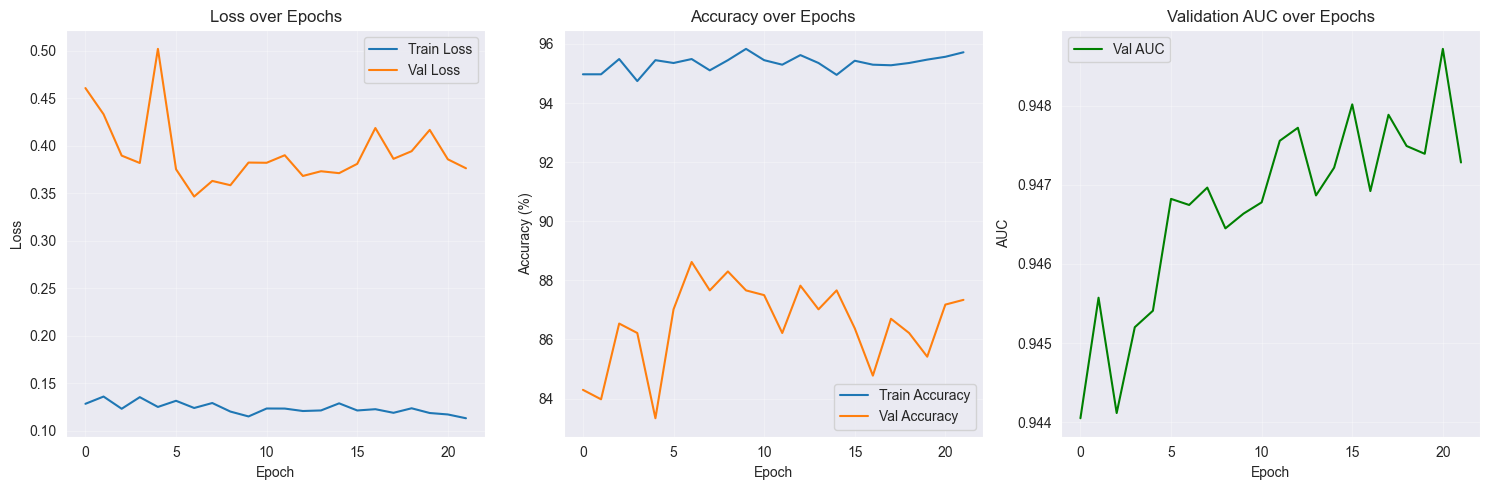

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc

plt.figure(figsize=(15, 5))

# Loss plot
plt.subplot(1, 3, 1)
plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Val Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(alpha=0.3)

# Accuracy plot
plt.subplot(1, 3, 2)
plt.plot(history['train_acc'], label='Train Accuracy')
plt.plot(history['val_acc'], label='Val Accuracy')
plt.title('Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(alpha=0.3)

# AUC plot
plt.subplot(1, 3, 3)
plt.plot(history['val_auc'], label='Val AUC', color='green')
plt.title('Validation AUC over Epochs')
plt.xlabel('Epoch')
plt.ylabel('AUC')
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('training_history.png', dpi=150)
plt.show()

In [38]:
# Get final predictions
model.eval()
all_probs = []
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in validation_ds:
        images = images.to(DEVICE)
        outputs = model(images)
        probs = torch.sigmoid(outputs)

        all_probs.extend(probs.cpu().numpy().ravel())
        all_preds.extend((probs.cpu().numpy() > 0.35).astype(int).ravel())
        all_labels.extend(labels.numpy())

all_labels = np.array(all_labels)
all_preds = np.array(all_preds)
all_probs = np.array(all_probs)

# Get class names from the underlying dataset
# Assuming your validation_ds was created from a dataset with .classes attribute
class_names = validation_ds.dataset.classes if hasattr(validation_ds, 'dataset') else ['Normal', 'Pneumonia']

# Classification report
print("\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=class_names))


Classification Report:
              precision    recall  f1-score   support

      NORMAL       0.90      0.71      0.80       234
   PNEUMONIA       0.85      0.95      0.90       390

    accuracy                           0.86       624
   macro avg       0.88      0.83      0.85       624
weighted avg       0.87      0.86      0.86       624




ROC-AUC: 0.9467


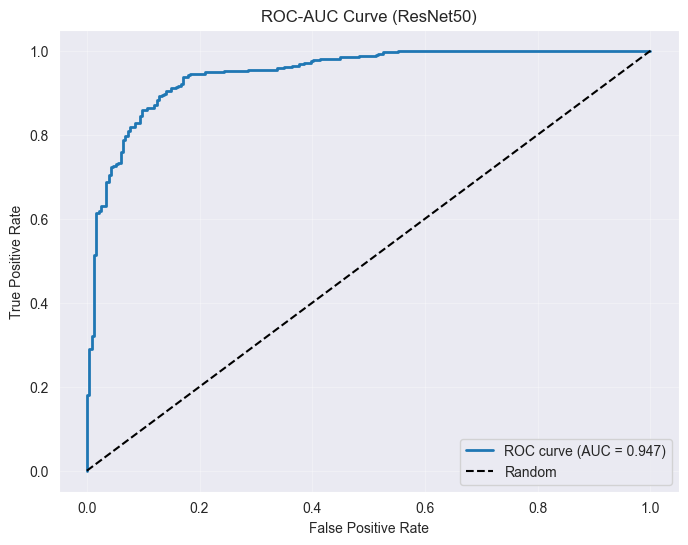

In [39]:
# ROC-AUC
fpr, tpr, _ = roc_curve(all_labels, all_probs)
roc_auc = auc(fpr, tpr)
print(f"\nROC-AUC: {roc_auc:.4f}")

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.3f})', linewidth=2)
plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-AUC Curve (ResNet50)')
plt.legend()
plt.grid(alpha=0.3)
plt.savefig('roc_curve.png', dpi=150)
plt.show()



Confusion Matrix:
[[167  67]
 [ 18 372]]


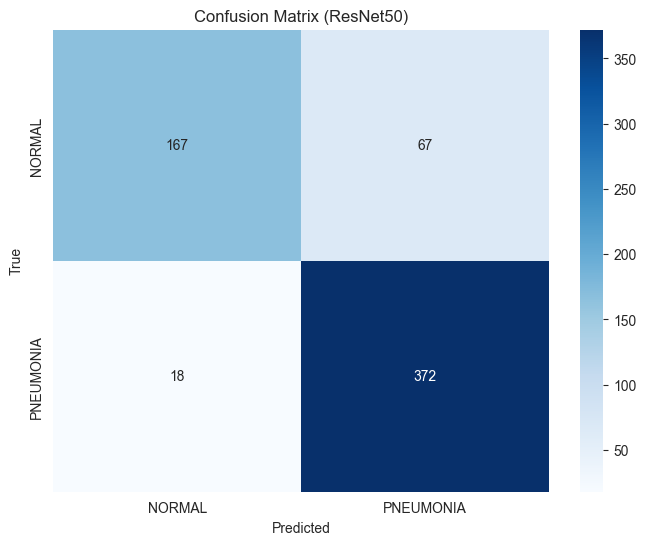


CLINICAL METRICS
Sensitivity (Recall for Pneumonia): 95.38%
Specificity (Recall for Normal): 71.37%
Precision: 84.74%
F1-Score: 89.75%
Accuracy: 86.38%

Models saved successfully!


In [40]:
# Confusion matrix
cm = confusion_matrix(all_labels, all_preds)
print("\nConfusion Matrix:")
print(cm)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix (ResNet50)')
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

# Calculate metrics (for binary classification)
tn, fp, fn, tp = cm.ravel()
sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
precision = tp / (tp + fp) if (tp + fp) > 0 else 0
f1 = 2 * (precision * sensitivity) / (precision + sensitivity) if (precision + sensitivity) > 0 else 0

print("\n" + "=" * 60)
print("CLINICAL METRICS")
print("=" * 60)
print(f"Sensitivity (Recall for Pneumonia): {sensitivity:.2%}")
print(f"Specificity (Recall for Normal): {specificity:.2%}")
print(f"Precision: {precision:.2%}")
print(f"F1-Score: {f1:.2%}")
print(f"Accuracy: {(tp + tn) / (tp + tn + fp + fn):.2%}")
print("=" * 60)

torch.save(model.state_dict(), 'pneumonia_resnet50_weights.pth')

full_model = {
    'model_state_dict': model.state_dict(),
    'class_names': class_names,
    'threshold': 0.35
}
torch.save(full_model, 'pneumonia_resnet50_complete.pth')
print("\nModels saved successfully!")